In [1]:
import pandas as pd

df = pd.read_csv("/content/supplied_training_data.csv")

df.head()

,sequence,temp_c,humidity_pct
0,0,27.9,54.4
1,1,27.9,54.5
2,2,27.9,54.7
3,3,27.9,54.8
4,4,27.9,54.8


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31347 entries, 0 to 31346
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sequence      31347 non-null  int64  
 1   temp_c        31346 non-null  float64
 2   humidity_pct  31346 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 734.8 KB


In [3]:
df.describe()

,sequence,temp_c,humidity_pct
count,31347.000000,31346.000000,31346.000000
mean,15673.000000,29.515271,71.199815
std,9049.243781,3.121943,14.852801
min,0.000000,25.300000,11.500000
25%,7836.500000,27.900000,55.100000
50%,15673.000000,29.800000,80.600000
75%,23509.500000,30.100000,81.800000
max,31346.000000,61.800000,91.000000


In [4]:
df = df.dropna(subset=["temp_c", "humidity_pct"]).copy()

print(df.shape)

(31346, 3)


In [5]:
print("Temperature: ", df["temp_c"].min(), df["temp_c"].max())
print("Humidity: ", df["humidity_pct"].min(), df["humidity_pct"].max())

Temperature:  25.3 61.8
Humidity:  11.5 91.0


## Histograma

array([[<Axes: title={'center': 'temp_c'}>,
        <Axes: title={'center': 'humidity_pct'}>]], dtype=object)

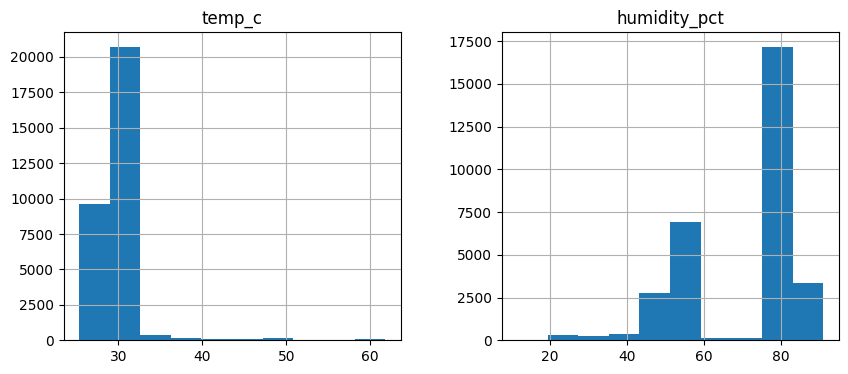

In [6]:
df[["temp_c", "humidity_pct"]].hist(figsize=(10,4))

ADEQUADO
umidade entre 40% e 60%
e temperatura < 32 °C

ATENÇÃO
umidade entre 30% e 40%
ou entre 60% e 70%
ou temperatura entre 32 e 35 °C

ALERTA
umidade < 30%
ou umidade > 70%
ou temperatura > 35 °C

In [7]:
def classificar(row):
    temp = row["temp_c"]
    umid = row["humidity_pct"]

    # ALERTA
    if temp >= 38 or umid < 25 or umid > 80:
        return "ALERTA"

    # ATENCAO
    elif temp >= 32 or umid < 40 or umid > 60:
        return "ATENCAO"

    # ADEQUADO
    else:
        return "ADEQUADO"

df["classe"] = df.apply(classificar, axis=1)

df.head()

,sequence,temp_c,humidity_pct,classe
0,0,27.9,54.4,ADEQUADO
1,1,27.9,54.5,ADEQUADO
2,2,27.9,54.7,ADEQUADO
3,3,27.9,54.8,ADEQUADO
4,4,27.9,54.8,ADEQUADO


In [8]:
df["classe"].value_counts()

print(df["classe"].value_counts())
print(df["classe"].value_counts(normalize=True) * 100)

classe
ALERTA      18861
ADEQUADO     9617
ATENCAO      2868
Name: count, dtype: int64
classe
ALERTA      60.170357
ADEQUADO    30.680151
ATENCAO      9.149493
Name: proportion, dtype: float64


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Entradas do modelo
X = df[["temp_c", "humidity_pct"]].values

# Mapeamento das classes
mapa_classes = {
    "ADEQUADO": 0,
    "ATENCAO": 1,
    "ALERTA": 2
}

y = df["classe"].map(mapa_classes).values

print(X.shape)
print(y.shape)

(31346, 2)
(31346,)


## Divisão treino e teste.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

Treino: (25076, 2)
Teste : (6270, 2)


## Normalização: média zero e desvio padrão igual a 1

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Media:", scaler.mean_)
print("Desvio:", scaler.scale_)

Media: [29.51127373 71.20810735]
Desvio: [ 3.11069686 14.84787877]


## Balancear pelo peso das classes.

In [12]:
classes = np.unique(y_train)

pesos = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, pesos))

print(class_weights)

{np.int64(0): np.float64(1.0863876613811627), np.int64(1): np.float64(3.643708224353386), np.int64(2): np.float64(0.553994344291269)}


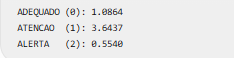

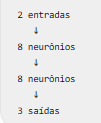 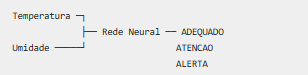

## Rede Neural

In [13]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

## Treinar e avaliar

In [14]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8882 - loss: 0.6874 - val_accuracy: 0.9675 - val_loss: 0.3282
Epoch 2/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9833 - loss: 0.2340 - val_accuracy: 0.9944 - val_loss: 0.1277
Epoch 3/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9860 - loss: 0.1025 - val_accuracy: 0.9892 - val_loss: 0.0779
Epoch 4/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9876 - loss: 0.0758 - val_accuracy: 0.9960 - val_loss: 0.0719
Epoch 5/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9857 - loss: 0.0654 - val_accuracy: 0.9733 - val_loss: 0.0684
Epoch 6/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9854 - loss: 0.0592 - val_accuracy: 0.9733 - val_loss: 0.0645
Epoch 7/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9824 - loss: 0.0559 - val_accuracy: 0.9966 - val_loss: 0.0558
Epoch 8/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9821 - loss: 0.0532 - val_accuracy: 0.

In [15]:
loss, acc = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Loss:", loss)
print("Accuracy:", acc)

Loss: 0.03295929357409477
Accuracy: 0.9762360453605652


In [29]:
from sklearn.metrics import classification_report
import numpy as np

y_prob = model.predict(X_test_scaled)
y_pred_32 = np.argmax(y_prob, axis=1)

print(
    classification_report(
        y_test,
        y_pred_32,
        target_names=["ADEQUADO", "ATENCAO", "ALERTA"]
    )
)

196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    ADEQUADO       1.00      1.00      1.00      1923
     ATENCAO       0.80      0.98      0.88       574
      ALERTA       1.00      0.96      0.98      3773

    accuracy                           0.98      6270
   macro avg       0.93      0.98      0.95      6270
weighted avg       0.98      0.98      0.98      6270



In [17]:
model.save("/content/modelo_climatico_float32.keras")

## Quantização int8

In [18]:
def representative_dataset():
    for i in range(200):
        sample = X_train_scaled[i:i+1].astype(np.float32)
        yield [sample]

In [19]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()

Saved artifact at '/tmp/tmpnzjx1cby'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137992243852112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942572176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942571792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942572560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942572368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942572944: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [20]:
with open("/content/modelo_climatico_int8.tflite", "wb") as f:
    f.write(tflite_int8)

In [21]:
import os

float_size = os.path.getsize(
    "/content/modelo_climatico_float32.keras"
)

int8_size = os.path.getsize(
    "/content/modelo_climatico_int8.tflite"
)

print("Float32:", float_size, "bytes")
print("INT8:", int8_size, "bytes")

Float32: 27010 bytes
INT8: 3024 bytes


In [22]:
converter_float = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_float = converter_float.convert()

with open("/content/modelo_climatico_float32.tflite", "wb") as f:
    f.write(tflite_float)

Saved artifact at '/tmp/tmph6seesax'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137992243852112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942572176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942571792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942572560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942572368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991942572944: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [34]:
float_tflite_size = os.path.getsize(
    "/content/modelo_climatico_float32.tflite"
)

int8_size = os.path.getsize(
    "/content/modelo_climatico_int8.tflite"
)

print("TFLite Float32:", float_tflite_size, "bytes")
print("TFLite INT8   :", int8_size, "bytes")

reducao = (1 - int8_size / float_tflite_size) * 100

print(f"Reducao: {reducao:.2f}%")

TFLite Float32: 2592 bytes
TFLite INT8   : 3024 bytes
Reducao: -16.67%


In [24]:
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(
    model_path="/content/modelo_climatico_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUT:")
print(input_details)

print("\nOUTPUT:")
print(output_details)

INPUT:
[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([1, 2], dtype=int32), 'shape_signature': array([-1,  2], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.053732119500637054, -63), 'quantization_parameters': {'scales': array([0.05373212], dtype=float32), 'zero_points': array([-63], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

OUTPUT:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [25]:
input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("Input scale:", input_scale)
print("Input zero_point:", input_zero_point)

print("Output scale:", output_scale)
print("Output zero_point:", output_zero_point)

Input scale: 0.053732119500637054
Input zero_point: -63
Output scale: 0.00390625
Output zero_point: -128


In [26]:
y_pred_int8 = []

for sample in X_test_scaled:

    sample = sample.reshape(1, 2).astype(np.float32)

    # Float32 -> INT8
    sample_int8 = (
        sample / input_scale + input_zero_point
    ).round()

    sample_int8 = np.clip(
        sample_int8,
        -128,
        127
    ).astype(np.int8)

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    output_int8 = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # INT8 -> Float32
    output_float = (
        output_int8.astype(np.float32) - output_zero_point
    ) * output_scale

    classe = np.argmax(output_float[0])

    y_pred_int8.append(classe)

y_pred_int8 = np.array(y_pred_int8)

## Quantizado: Int8

In [31]:
from sklearn.metrics import classification_report, accuracy_score
print("Int8")
print(
    classification_report(
        y_test,
        y_pred_int8,
        target_names=[
            "ADEQUADO",
            "ATENCAO",
            "ALERTA"
        ]
    )
)

print(
    "Accuracy INT8:",
    accuracy_score(y_test, y_pred_int8)
)

Int8
              precision    recall  f1-score   support

    ADEQUADO       1.00      1.00      1.00      1923
     ATENCAO       0.80      0.98      0.88       574
      ALERTA       1.00      0.96      0.98      3773

    accuracy                           0.98      6270
   macro avg       0.93      0.98      0.95      6270
weighted avg       0.98      0.98      0.98      6270

Accuracy INT8: 0.9759170653907496


## Original: float32

In [33]:
print('Float32')
print(
    classification_report(
        y_test,
        y_pred_32,
        target_names=[
            "ADEQUADO",
            "ATENCAO",
            "ALERTA"
        ]
    )
)

print(
    "Accuracy Float32:",
    accuracy_score(y_test, y_pred_32)
)

Float32
              precision    recall  f1-score   support

    ADEQUADO       1.00      1.00      1.00      1923
     ATENCAO       0.80      0.98      0.88       574
      ALERTA       1.00      0.96      0.98      3773

    accuracy                           0.98      6270
   macro avg       0.93      0.98      0.95      6270
weighted avg       0.98      0.98      0.98      6270

Accuracy Float32: 0.9762360446570972


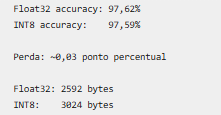

Quantização não significa obrigatoriamente:
arquivo .tflite menor em todos os casos.

Beneficios:

- operações inteiras


- menor custo computacional

- menor uso de memória para tensores

- melhor adequação a microcontroladores

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 248 (996.00 B)

In [36]:
total_params = model.count_params()

mem_float32 = total_params * 4   # 4 bytes por parâmetro
mem_int8 = total_params * 1      # 1 byte por parâmetro

print("Total de parâmetros:", total_params)
print("Memória teórica Float32:", mem_float32, "bytes")
print("Memória teórica INT8   :", mem_int8, "bytes")

reducao_teorica = (1 - mem_int8 / mem_float32) * 100

print(f"Redução teórica dos pesos: {reducao_teorica:.2f}%")

Total de parâmetros: 123
Memória teórica Float32: 492 bytes
Memória teórica INT8   : 123 bytes
Redução teórica dos pesos: 75.00%


A quantização reduz a representação numérica dos pesos de 32 bits para 8 bits, o que corresponde teoricamente a 75% de redução na memória ocupada pelos parâmetros. Porém, neste modelo extremamente pequeno, o arquivo TFLite INT8 ficou maior devido ao overhead adicional de quantização.

## Levar modelo quantizado para o simulador com dht22

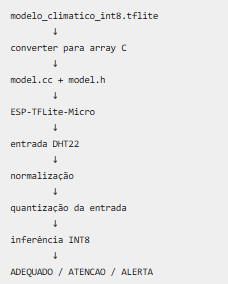

In [38]:
from google.colab import files
files.download("/content/modelo_climatico_int8.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
from pathlib import Path

tflite_path = Path("/content/modelo_climatico_int8.tflite")
data = tflite_path.read_bytes()

with open("/content/model.cc", "w", encoding="utf-8") as f:
    f.write('#include "model.h"\n\n')

    f.write("const unsigned char modelo_climatico_int8_tflite[] = {\n")

    for i, byte in enumerate(data):
        if i % 12 == 0:
            f.write("    ")

        f.write(f"0x{byte:02x}")

        if i != len(data) - 1:
            f.write(", ")

        if i % 12 == 11:
            f.write("\n")

    if len(data) % 12 != 0:
        f.write("\n")

    f.write("};\n\n")

    f.write(
        f"const unsigned int modelo_climatico_int8_tflite_len = {len(data)};\n"
    )

print("model.cc criado:", len(data), "bytes do modelo")

model.cc criado: 3024 bytes do modelo


In [40]:
with open("/content/model.h", "w", encoding="utf-8") as f:
    f.write("""#ifndef MODEL_H
#define MODEL_H

extern const unsigned char modelo_climatico_int8_tflite[];
extern const unsigned int modelo_climatico_int8_tflite_len;

#endif
""")

In [41]:
from google.colab import files

files.download("/content/model.cc")
files.download("/content/model.h")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
print("MEAN:", scaler.mean_)
print("STD :", scaler.scale_)

MEAN: [29.51127373 71.20810735]
STD : [ 3.11069686 14.84787877]
